In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from matplotlib import pyplot as plt

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


The Laplace transform is a time frequency transform allowing the analysis of continuous-domain LTI systems in terms of their impulse response behavior. This is relevant when designing and investigating filters or other processing units with a scope on their **stability**. 
The single-sided Laplace transform is defined by the following integral:

$$
F(s) = \int\limits_0^\infty f(t) e^{-s t}  dt  
$$

$s$ is the Laplace operator:

$$
s = \sigma + j \omega 
$$


For $\sigma=0$, the Laplace transform becomes the Fourier Transform:

$$
F(s) = \int\limits_0^\infty f(t) e^{-j \omega t}  dt = F(\omega)
$$


An addition in the exponent can be decomposed into two exponential terms:

$$\begin{eqnarray}
F(s) & = & \int\limits_0^\infty e^{-\sigma t -j \omega t} f(t) dt \\
& = & \int\limits_0^\infty e^{-\sigma t} \ e^{-j \omega t} f(t) dt
\end{eqnarray}$$

- The term $e^{-\sigma t}$ is referred to as the **decay term**.
- $ e^{-j \omega t}$ is called the **frequency term**.

With these two terms, the Laplace transform can be considered an extension of the Fourier transform.
While the latter *only* gives information on the frequency content of signals, the Laplace transform encodes the temporal behavior with the decay term and can be used to analyze the stability of LTI systems.


  

-------

# Visualisation

The following plots visualize the influence of the decay term and the frequency term.

## Changing $\sigma$

$\sigma$ is the decay factor. For $\sigma > 0$, the transform increases with time - this means an impulse response with such behavior belongs to an unstable system (for that frequency).
For $\sigma<0$, the transform decreases, indicating a stable system (for that frequency).
For $\sigma=0$ we see the Fourier terms.


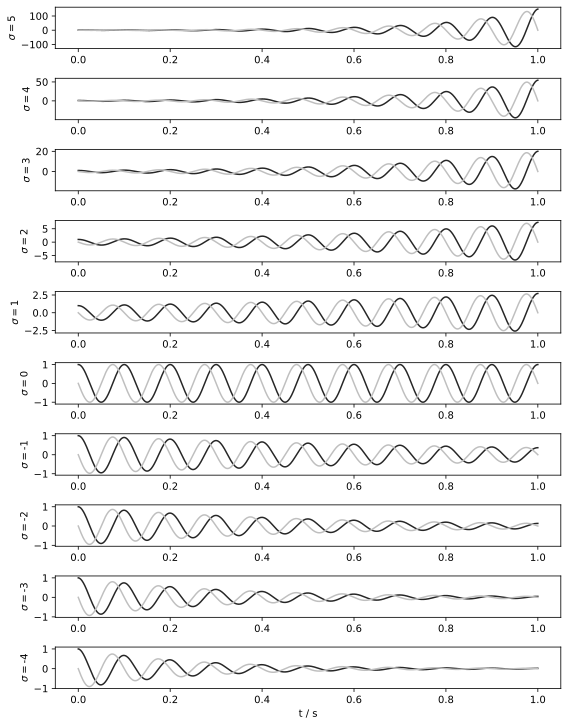

In [2]:
def laplace(t, s, w, r):
        
    out = np.zeros(len(t))
    
    for i in range(len(t)):
        val = t[i]
            
        if r ==1:    
            out[i] = np.real(np.exp(-s*val) * np.exp(-1j * w * val))
        else:
            out[i] = np.imag(np.exp(-s*val) * np.exp(-1j * w * val))
            
    return out



t = np.linspace(0,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 10))

for i in range(10):    
    
    y = laplace(t,(i-5),2 *np.pi *10,1)  
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,(i-5),2 *np.pi *10,0)
    axs[i].plot(t,y, color = [0.75,0.75,0.75])


    axs[i].set_ylabel('$\sigma=$'+str(-1*(i-5))); 

plt.tight_layout()       
plt.xlabel('t / s');
        
    

## Changing $\omega$

The following plots show different values for $\omega$ with a fixed decay term.
This means different frequencies are *compared* with the same decay pattern.


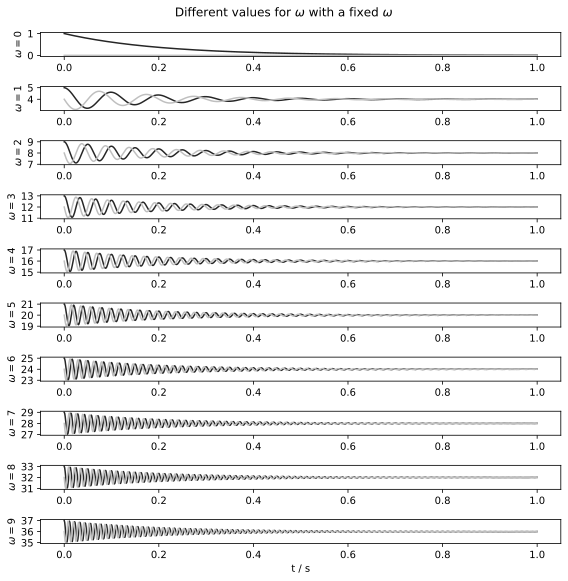

In [3]:
t = np.linspace(0,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 8))
fig.suptitle('Different values for $\omega$ with a fixed $\omega$')

for i in range(10):        

    y = laplace(t,5,2 *np.pi *i*10,1) + 4*i
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,5,2 *np.pi *i*10,0) + 4*i
    axs[i].plot(t,y, color = [0.75,0.75,0.75])
    axs[i].set_ylabel('$\omega=$'+str(i)); 


plt.tight_layout()   
plt.xlabel('t / s');
    

-----

# Analysing Systems with the Laplace Transform

Analysing an LTI system with the Laplace transform means transforming its impulse response $h(t)$:
$$
H(s) = \int\limits_0^\infty h(t) e^{-s t}  dt  
$$

The result - $H(s)$ will show how different frequencies decay (or not).

## RC Lowpass

The schematic below shows a first order RC lowpass.
It is the most simple passive analog filter.


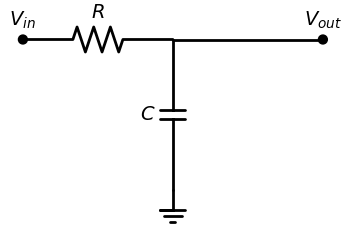

In [4]:
d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Resistor().label('$R$'))
d.push() 

d.add(e.Capacitor().down().label('$C$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()


Without deriving it - with the resistance $R$ of the resistor, the capacitance $C$ of the capacitor 
and $V_{in}$ and $V_{out}$ for input and output voltage, respectively, 
the transfer function of this circuit is:

$$\begin{eqnarray}
\frac{V_{out}}{V_{in}} & =&  \frac{\frac{1}{sC}}{R+\frac{1}{sC}} \\
 & =&  \frac{1}{1+sRC} 
\end{eqnarray}
$$

$RC$ is known as the **time constant** $\tau$:

$$
\tau = RC
$$

The cutoff frequency $\omega_c$ is related to the time constant:

$$
\omega_c = \frac{1}{\tau}
$$

Inserting:

$$
H(s) = \frac{1}{1+\frac{s}{\omega_c}}
$$


With $\omega = 2 \pi f$ this results in:


$$
H(s) = \frac{1}{1+\frac{s}{2 \pi f_c}}
$$

-----

# Poles and Zeros

The above transfer function can be analysed in terms poles and zeros.

Zeros occur when the denominator is $0$. There are no zeros in this plot.

Poles occur when the nominator is $0$. This circuit has a pole at:

$$
s = \frac{-1}{\tau} = -\omega_c
$$

It is negative and thus always stable.

----

## The S-Plane

The result of the Laplace transform can be visualized in the S-Plane, in its real and imaginary part:

$$
s = \sigma + j \omega 
$$

The decay term is plotted along the x-axis - the frequency term along the y-asis.
This represenation directly reveals the stability of a system.

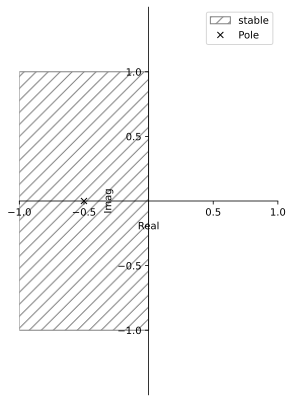

In [5]:
fig, ax = plt.subplots()

fig.set_figheight(7)
fig.set_figwidth(7)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)


plt.fill_between([-1,0], [1,1],-1 ,color='none',hatch='//',edgecolor="gray",label='stable');
plt.plot(-0.5,0,'xk',label='Pole');

plt.xlim(-1,1)

plt.xlabel('Real')
plt.ylabel('Imag')

plt.legend(loc=1)
plt.show()